In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter

import anndata as ad
import scanpy as sc
import cellspec as spc

%matplotlib inline

In [7]:
data = pd.read_csv('/fh/working/srivatsan_s/Dustin/worm6-full-align/pooled_sc_qc_metrics.csv', index_col='barcode')
data

,sample,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini,bam_path
barcode,,,,,,,,,,,,,,,,,,
A10_A7_E5_G3_worm6_UDI1,worm6_UDI1,365038,59016,0.161671,116,173.9,5156,0.174732,28935,0.490291,786,0.016206,0.001582,0.000325,0.035993,0,0.978133,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
A10_A8_F4_G2_worm6_UDI1,worm6_UDI1,458618,23726,0.051734,116,169.7,2054,0.173143,11355,0.478589,245,0.008594,0.000401,0.000044,0.014552,0,0.983056,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
A10_A8_F5_G1_worm6_UDI1,worm6_UDI1,947344,479120,0.505751,113,171.6,41436,0.172967,230537,0.481168,5741,0.151677,0.008827,0.001088,0.295635,0,0.796065,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
A10_A8_F6_B2_worm6_UDI1,worm6_UDI1,823686,564178,0.684943,112,175.2,51099,0.181145,299796,0.531385,3755,0.230681,0.002779,0.000228,0.355335,0,0.675681,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
A10_A9_B5_E2_worm6_UDI1,worm6_UDI1,371374,222946,0.600327,112,170.0,18937,0.169880,108749,0.487782,1756,0.116787,0.000396,0.000173,0.139397,0,0.640650,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_B8_C4_B2_worm6_UDI24,worm6_UDI24,368302,180984,0.491401,113,179.3,19764,0.218406,79725,0.440509,2606,0.038237,0.005300,0.001252,0.105120,0,0.958917,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
H12_C9_E6_A2_worm6_UDI24,worm6_UDI24,343024,159852,0.466008,112,299.1,18531,0.231852,70235,0.439375,3637,0.041829,0.003163,0.000519,0.091356,0,0.947460,/fh/working/srivatsan_s/Dustin/worm6-full-alig...
H12_D9_H6_D3_worm6_UDI24,worm6_UDI24,878274,476590,0.542644,112,176.2,52924,0.222094,217302,0.455952,6464,0.146286,0.006876,0.000814,0.273249,0,0.800379,/fh/working/srivatsan_s/Dustin/worm6-full-alig...


In [9]:
data.columns

Index(['sample', 'total_reads', 'aligned_reads', 'pct_aligned',
       'mean_read_length', 'mean_insert_size', 'read_duplicates',
       'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads',
       'pct_1x', 'pct_5x', 'pct_10x', 'mean_coverage', 'median_coverage',
       'gini', 'bam_path'],
      dtype='object')

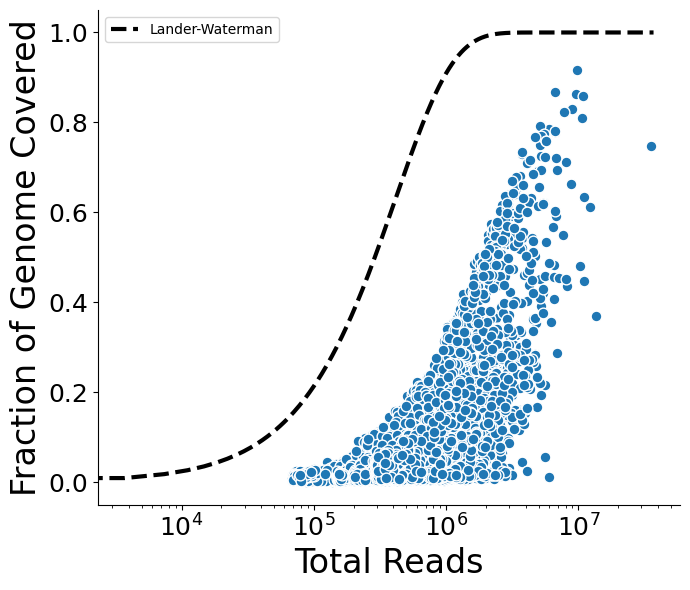

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

G = 100286401
RL = data.mean_insert_size.mean()
x_theory = np.linspace(0, data['total_reads'].max() * 1.05, 10000)
y_theory = 1 - np.exp(-(x_theory * RL / G))

ax.plot(x_theory, y_theory, color='black', linestyle='--', linewidth=3, label='Lander-Waterman')
sns.scatterplot(
    data=data,
    x="total_reads",
    y="pct_1x",
    ec="white",
    linewidth=1,
    s=60,
    alpha=1,
    zorder=3,
    ax=ax,
)
ax.set_xlabel("Total Reads", fontsize=24)
ax.set_ylabel("Fraction of Genome Covered", fontsize=24)
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
ax.tick_params(labelsize=18)

plt.xscale('log')

sns.despine()
plt.tight_layout()
# fig.savefig('', bbox_inches='tight', dpi=600)

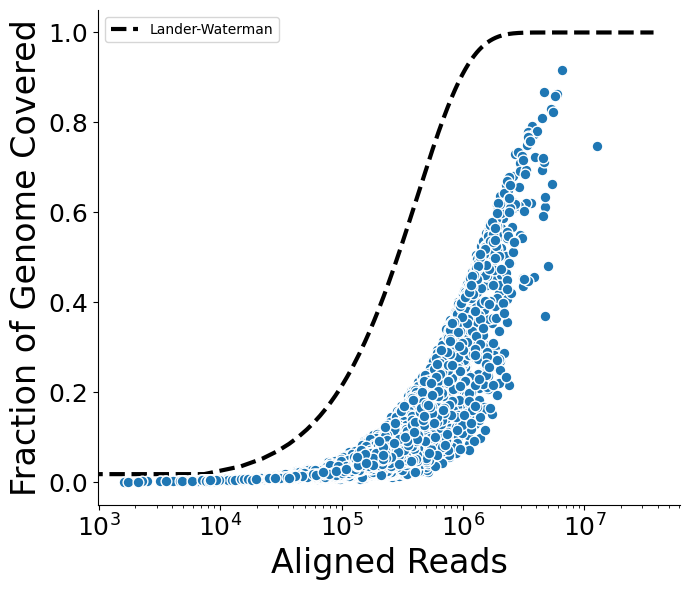

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

G = 100286401
RL = data.mean_insert_size.mean()
x_theory = np.linspace(0, data['total_reads'].max() * 1.05, 10000)
y_theory = 1 - np.exp(-(x_theory * RL / G))

ax.plot(x_theory, y_theory, color='black', linestyle='--', linewidth=3, label='Lander-Waterman')
sns.scatterplot(
    data=data,
    x="aligned_reads",
    y="pct_1x",
    ec="white",
    linewidth=1,
    s=60,
    alpha=1,
    zorder=3,
    ax=ax,
)
ax.set_xlabel("Aligned Reads", fontsize=24)
ax.set_ylabel("Fraction of Genome Covered", fontsize=24)
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
ax.tick_params(labelsize=18)

plt.xscale('log')
sns.despine()
plt.tight_layout()
# fig.savefig('', bbox_inches='tight', dpi=600)